### Simulation Results

In [ ]:
import numpy as np, pandas as pd
import importlib
import test_WTM as wtm, watts_model as nwm
import gudhi_persistence as gp
import utilsA1 as utils
import os, networkx as nx
from sklearn.decomposition import PCA

from lifelines import CoxTimeVaryingFitter


In [ ]:
importlib.reload(wtm)
importlib.reload(nwm)
importlib.reload(utils)
importlib.reload(gp)

PATH = os.getcwd()
output_file = "FLCRM"
params_temp_list = {'num_nodes': 100, 'num_neighbor_nodes': 1,
                    'total_random_edges': 20, 'distance_threshold': 5, 'weighted': True,
                    'ngeo_placement': 'random.choice', 'n_seeds': 2, 'node_active_threshold': 0.1,
                    'upper_weight_limit': 2,  'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'all_combinations', 'calculate_representation': True,
                    'bandwidth': 0.1, 'num_landscapes': 3, 'resolution': 50}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 2

# df, activation_results = wtm.main_sims(params_list=[params_temp_list],
#                    output_file=output_file, save_files=False)

#### Homology Representation

In [ ]:

importlib.reload(gp)
importlib.reload(nwm)
importlib.reload(wtm)

params_temp_list['seeding_method'] = 'cluster_seeding'
params_temp_list['calculate_representation'] = bool(False)
graph, seed_nodes = nwm.simulate_contagion_map(params=params_temp_list)
adjacency_matrix = nx.to_numpy_array(graph, dtype=float, weight=None)
weight_0 = nx.to_numpy_array(graph, weight='weight', nonedge=1e9)

graph, snapshots, activation_times, results = nwm.simulate_contagion_realization(graph = graph, init_seeds = seed_nodes[0], params = params_temp_list,
max_steps = 100, adjacency_matrix = adjacency_matrix, weight_0 = weight_0)

utils.visualize_step_animation_new(G=graph, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))
print(f"Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/{output_file}.html")
print(activation_times)

In [ ]:
importlib.reload(gp)
importlib.reload(nwm)
betti_nums, persistence, persistence_intervals_for_diagram = gp.compute_persistence(graph=graph, activation_times=activation_times, max_dim=2)

In [ ]:
print(persistence)

In [ ]:
gp.persistence_barcodes(persistence_intervals_for_diagram)

In [ ]:
importlib.reload(gp)
# test_pers_0 = np.array([(birth, death) for dim, intervla in persistence if dim == 0])
L, I, E, params = gp.persistence_representation_t(persistence, num_landscapes=4)

# landscape
# plt.plot(df.loc[row_id, 'L_0'][:resolution])
# plt.plot(df.loc[row_id, 'L_1'][resolution: resolution*2])
# plt.plot(df.loc[row_id, 'L_2'][resolution*2:resolution*3])
# plt.title("Landscape")
# plt.show()

In [ ]:
type(L[0][0])

In [ ]:
resolution = params['resolution']
timestep = 7
test_resolution = 10
plt.plot(L[timestep][0][:resolution])
plt.plot(L[timestep][0][resolution: resolution*2])
plt.plot(L[timestep][0][resolution*2: resolution*3])
# plt.plot(L[0][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

In [ ]:
gp.betti_nums_over_time(betti_over_time=betti_numbers)

In [ ]:
gp.persistence_diagram(persistence_intervals_for_diagram)

In [ ]:

gp.persistence_barcodes(persistence_intervals_for_diagram)

#### Persistence Images / Landscapes

In [ ]:
row_id = 12
resolution = params_temp_list['resolution']
plt.imshow(np.flip(np.reshape(df.loc[row_id, 'I_0'], [resolution,resolution]), 0))
plt.title("Persistence Image")
plt.show()

In [ ]:
plt.plot(df.loc[row_id, 'L_0'][:resolution])
plt.plot(df.loc[row_id, 'L_1'][resolution: resolution*2])
plt.plot(df.loc[row_id, 'L_2'][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

### Test Persistent Diagram Importance in PCA

In [1]:
import random
import pandas as pd
import numpy as np, networkx as nx, gudhi_persistence as gp, watts_model as nwm, matplotlib.pyplot as plt, utilsA1 as utils
import os, importlib

from sklearn.decomposition import PCA
from lifelines import CoxTimeVaryingFitter


In [2]:
num_samples = 20

params_list = []
for _ in range(num_samples):
    num_nodes = random.choice([30])
    weighted = True
    n_seeds = random.choice([2])
    node_active_threshold = random.choice([0.02, 0.025, 0.03, 0.1])
    num_neighbor_nodes = random.choice([3, 4])
    distance_threshold = random.randint(num_neighbor_nodes + 1, num_neighbor_nodes + 2)
    total_random_edges = random.choice([ 20, 30, 40])
    upper_weight_limit = random.randint(10, 20)
    skew_power = random.randint(2, 4)
    seed_cluster_distance = 20
    ngeom_edges_in_persistence = False
    max_persistence_dim = 2
    threshold_sum = sum(range(num_nodes))
    seeding_method = 'all_combinations'
    ngeo_placement = 'random.choice'
    calculate_representation = True

    param = {
            'num_nodes': num_nodes,  # fixed
            'num_neighbor_nodes': num_neighbor_nodes,
            'total_random_edges': total_random_edges,
            'distance_threshold': distance_threshold,
            'weighted': weighted,
            'ngeo_placement': ngeo_placement,  # other 'ngeo_per_node'
            'n_seeds': n_seeds,
            'node_active_threshold': node_active_threshold,
            'upper_weight_limit': upper_weight_limit,
            'skew_power': skew_power,
            'seed_cluster_distance': seed_cluster_distance,
            'ngeom_edges_in_persistence': ngeom_edges_in_persistence,
            'max_persistence_dim': max_persistence_dim,
            'threshold_sum': threshold_sum,
            'seeding_method': seeding_method,
            'calculate_representation': calculate_representation,
            'bandwidth': 0.4
        }

    params_list.append(param)

In [3]:
param_df = pd.DataFrame(params_list)
param_df

,num_nodes,num_neighbor_nodes,total_random_edges,distance_threshold,weighted,ngeo_placement,n_seeds,node_active_threshold,upper_weight_limit,skew_power,seed_cluster_distance,ngeom_edges_in_persistence,max_persistence_dim,threshold_sum,seeding_method,calculate_representation,bandwidth
0,30,3,30,4,True,random.choice,2,0.020,20,4,20,False,2,435,all_combinations,True,0.4
1,30,4,20,6,True,random.choice,2,0.025,10,3,20,False,2,435,all_combinations,True,0.4
2,30,3,30,4,True,random.choice,2,0.030,16,2,20,False,2,435,all_combinations,True,0.4
3,30,3,40,5,True,random.choice,2,0.030,15,2,20,False,2,435,all_combinations,True,0.4
4,30,4,20,5,True,random.choice,2,0.030,19,2,20,False,2,435,all_combinations,True,0.4
5,30,3,20,4,True,random.choice,2,0.100,17,2,20,False,2,435,all_combinations,True,0.4
6,30,4,20,6,True,random.choice,2,0.020,20,4,20,False,2,435,all_combinations,True,0.4
7,30,3,40,5,True,random.choice,2,0.100,20,3,20,False,2,435,all_combinations,True,0.4
8,30,3,20,4,True,random.choice,2,0.030,13,4,20,False,2,435,all_combinations,True,0.4
9,30,4,30,5,True,random.choice,2,0.030,20,4,20,False,2,435,all_combinations,True,0.4


In [4]:
importlib.reload(nwm)
importlib.reload(gp)

# PATH = os.getcwd()
# output_file = 'FLCRM_test'
# output_file_path = os.path.join(PATH, 'Outputs', f"{output_file}.html")
df_temp, activation_results = nwm.main_sims(params_list=params_list, save_files=False)

Simulating Contagion Map for simulation: 0/20
Simulating Contagion Map for simulation: 1/20
Simulating Contagion Map for simulation: 2/20
Simulating Contagion Map for simulation: 3/20
Simulating Contagion Map for simulation: 4/20
Simulating Contagion Map for simulation: 5/20
Simulating Contagion Map for simulation: 6/20
Simulating Contagion Map for simulation: 7/20
Simulating Contagion Map for simulation: 8/20
Simulating Contagion Map for simulation: 9/20
Simulating Contagion Map for simulation: 10/20
Simulating Contagion Map for simulation: 11/20
Simulating Contagion Map for simulation: 12/20
Simulating Contagion Map for simulation: 13/20
Simulating Contagion Map for simulation: 14/20
Simulating Contagion Map for simulation: 15/20
Simulating Contagion Map for simulation: 16/20
Simulating Contagion Map for simulation: 17/20
Simulating Contagion Map for simulation: 18/20
Simulating Contagion Map for simulation: 19/20


In [5]:
df_temp.shape

(47323, 39)

In [6]:
# keep only realizations that have at least one row with state == 1
df_temp = df_temp[df_temp.groupby(['simulation_id', 'realization_id'])['state'].transform('max') == 1]
df_temp = df_temp[df_temp.groupby(['simulation_id', 'realization_id'])['state'].cumsum() <= 1]

In [7]:
# Define the list of front columns in desired order
front_columns = [
    "simulation_id", "realization_id", "time", "state",
    "node_active_threshold", "num_nodes", "num_neighbor_nodes",
    "total_random_edges", "num_active_nodes", "active_nodes"]

suffix_columns = [f"{prefix}_{i}" for prefix in ['H', 'L', 'I', 'E'] for i in range(3)]
all_columns = list(df_temp.columns)


middle_columns = [col for col in all_columns if col not in front_columns + suffix_columns]
df_temp = df_temp[front_columns + middle_columns + suffix_columns]
df_temp.drop(columns = suffix_columns, inplace=False).head(10)

,simulation_id,realization_id,time,state,node_active_threshold,num_nodes,num_neighbor_nodes,total_random_edges,num_active_nodes,active_nodes,...,seed_cluster_distance,ngeom_edges_in_persistence,max_persistence_dim,threshold_sum,seeding_method,calculate_representation,bandwidth,average_weight_per_edge,total_geo_edges,total_non_geo_edges
0,0,0,0,0,0.02,30,3,30,2,"[0, 1]",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
1,0,0,1,0,0.02,30,3,30,6,"[0, 1, 2, 3, 27, 28]",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
2,0,0,2,0,0.02,30,3,30,17,"[0, 1, 2, 3, 5, 6, 7, 9, 10, 17, 19, 24, 25, 2...",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
3,0,0,3,0,0.02,30,3,30,27,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 15,...",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
4,0,0,4,1,0.02,30,3,30,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
5,0,1,0,0,0.02,30,3,30,2,"[0, 2]",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
6,0,1,1,0,0.02,30,3,30,7,"[0, 1, 2, 3, 5, 9, 27]",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
7,0,1,2,0,0.02,30,3,30,17,"[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 17, 24, 26...",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
8,0,1,3,0,0.02,30,3,30,29,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30
9,0,1,4,1,0.02,30,3,30,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,20,False,2,435,all_combinations,True,0.4,3.611111,60,30


In [8]:
# df = df_temp[df_temp['state'] == 1]
df = df_temp
print(df.shape)
# df.drop(columns = suffix_columns,inplace=False).head(5)

(45760, 39)


In [9]:
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 5

df_pca = df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2'], how='left')


In [10]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Explained variance ratio: [0.50414068 0.73967356 0.80356093 0.85309727 0.89726685]
Skipping L_1 — no valid data.
Skipping L_2 — no valid data.
Explained variance ratio: [0.79035493 0.96416104 0.99393988 0.9986428  0.99955987]
Skipping I_1 — no valid data.
Skipping I_2 — no valid data.


In [11]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["simulation_id", "realization_id", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["simulation_id", "realization_id"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])


ordered_cols = ["id", "start", "stop", "state"] + landscape_cols + image_cols + essentials_cols
df_pca['id'] = df['simulation_id'].astype(str) + "_" + df['realization_id'].astype(str) # + df['time'].astype(str)

df_pca = df_pca[ordered_cols]
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_10888\2228916183.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,L_0_PC1,L_0_PC2,L_0_PC3,L_0_PC4,L_0_PC5,I_0_PC1,I_0_PC2,I_0_PC3,I_0_PC4,I_0_PC5,E_0,E_1,E_2
0,0_0,0,1.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
1,0_0,1,2.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
2,0_0,2,3.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
3,0_0,3,4.0,0,1.088864,1.904703,-0.433787,-0.388809,-0.678598,20.313995,11.636082,0.092042,0.660803,0.365628,4,0,0
4,0_0,4,5.0,1,1.088864,1.904703,-0.433787,-0.388809,-0.678598,20.313995,11.636082,0.092042,0.660803,0.365628,3,0,0
5,0_1,0,1.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
6,0_1,1,2.0,0,0.483346,-0.489817,-0.118721,-0.091917,0.066347,7.860861,-1.199395,-1.586186,-0.351451,0.057805,3,0,0
7,0_1,2,3.0,0,-1.224773,-0.044967,-0.077495,0.041272,0.017580,1.508361,-9.213071,2.043182,0.605086,-0.173267,5,0,0
8,0_1,3,4.0,0,-1.364603,-0.026178,-0.013530,-0.244527,0.092351,-10.685290,-8.317060,0.972836,0.554654,0.512654,4,0,0
9,0_1,4,5.0,1,-1.364603,-0.026178,-0.013530,-0.244527,0.092351,-10.685290,-8.317060,0.972836,0.554654,0.512654,4,0,0


### Time-Varying FLCRM

In [12]:
df_pca.drop(columns = ['E_1', 'E_2'], inplace=True)

ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 45760 periods, 8037 subjects, 8326 events>
         event col = 'state'
number of subjects = 8037
 number of periods = 45760
  number of events = 8326
partial log-likelihood = -66115.75
  time fit was run = 2025-09-16 08:28:05 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
L_0_PC1    1.11      3.03      0.06            1.00            1.22                2.71                3.39
L_0_PC2    0.99      2.69      0.04            0.91            1.08                2.48                2.93
L_0_PC3    0.24      1.27      0.05            0.14            0.33                1.15                1.39
L_0_PC4    0.27      1.31      0.05            0.18            0.36                1.19                1.44
L_0_PC5    0.54      1.72      0.06            0.43            0.65                1.54                1.92
I_0_PC1   -0.07      0.94      0.00           -0.07           -0.06                0.93                0.94
I_0_PC2   -0.12      0.88      0.01           -0.14           -0.11                0.87                0.89
I_0_PC3    0.12      1.13      0.01            0.11            0.14                1.11                1.14
I_0_PC4    0.16      1.17      0.01            0.13            0.18                1.14                1.19
I_0_PC5   -0.24      0.78      0.02           -0.29           -0.20                0.75                0.82
E_0       -0.15      0.86      0.01           -0.16           -0.13                0.85                0.88

           cmp to      z      p  -log2(p)
covariate                                
L_0_PC1      0.00  19.54 <0.005    280.11
L_0_PC2      0.00  22.99 <0.005    386.03
L_0_PC3      0.00   4.93 <0.005     20.21
L_0_PC4      0.00   5.71 <0.005     26.42
L_0_PC5      0.00   9.54 <0.005     69.25
I_0_PC1      0.00 -22.75 <0.005    378.21
I_0_PC2      0.00 -19.08 <0.005    267.32
I_0_PC3      0.00  16.81 <0.005    208.32
I_0_PC4      0.00  14.54 <0.005    156.73
I_0_PC5      0.00 -10.05 <0.005     76.48
E_0          0.00 -18.22 <0.005    243.91
---
Partial AIC = 132253.49
log-likelihood ratio test = 1447.28 on 11 df
-log2(p) of ll-ratio test = 1006.95

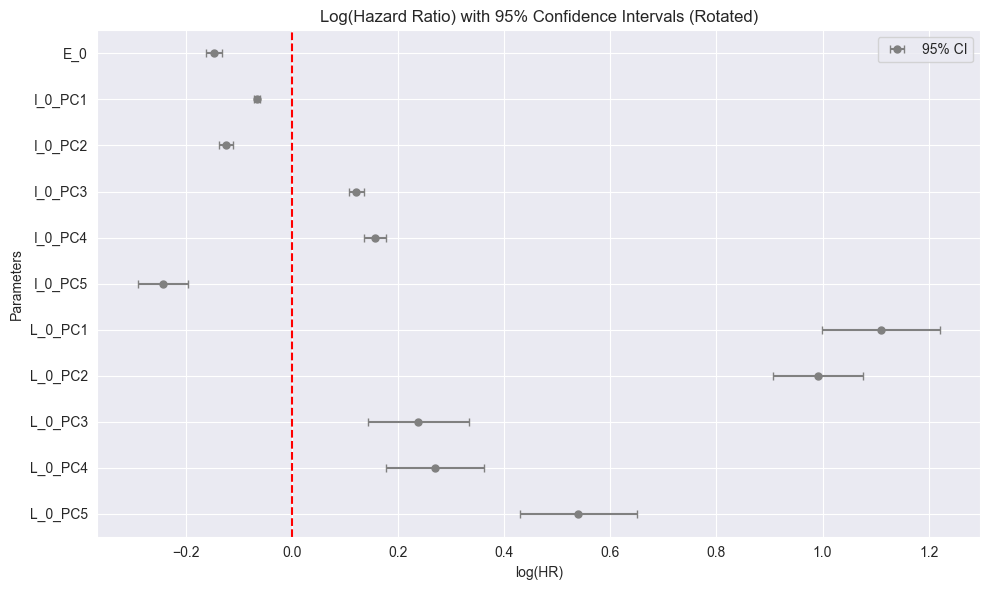

In [24]:
# sort teh values by param_ index name
param_names = ctv.params_.index
log_HR_values = ctv.params_.values
standard_errors = ctv.standard_errors_.values
df_plot = pd.DataFrame({
    'param_name': param_names,
    'log(HR)': log_HR_values,
    'std_error': standard_errors
})
sorted_df = df_plot.sort_values(by='param_name', ascending=False)


# re-create the erros bars from values
z_value = 1.96
sorted_df['lower_CI'] = sorted_df['log(HR)'] - z_value * sorted_df['std_error']
sorted_df['upper_CI'] = sorted_df['log(HR)'] + z_value * sorted_df['std_error']

# plot please
plt.figure(figsize=(10, 6))

plt.errorbar( sorted_df['log(HR)'], sorted_df['param_name'],
    xerr=[sorted_df['log(HR)'] - sorted_df['lower_CI'],
          sorted_df['upper_CI'] - sorted_df['log(HR)']], fmt='o', color='gray', markersize=5, capsize=3, label='95% CI')

plt.axvline(x=0, color = 'r', linestyle = '--')
plt.xlabel('log(HR)')
plt.ylabel('Parameters')
plt.title('Log(Hazard Ratio) with 95% Confidence Intervals (Rotated)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

<Axes: xlabel='log(HR) (95% CI)'>

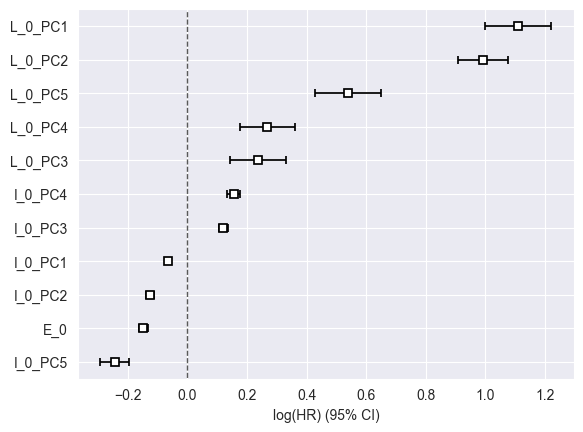

In [19]:
ctv.plot()